In [1]:
from pyscf import gto, scf, cc

a = 2 # bond length in a cluster
d = 100 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 2 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
basis = 'sto6g'
# for nc in nc_list:
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)

nfrozen = 0
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()[0]

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-14-generic', version='#14~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Jan 15 15:52:10 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Tue Mar  3 16:13:38 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 4
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA    

np.float64(-0.07928280181561755)

In [18]:
# example for PT2

options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 300,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'stoccsd2',
            'nslater': 10,
            'dt':0.005,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted.mixed_wave import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (2, 2)
# Number of basis functions: 4
# Number of Cholesky vectors: 6
#


In [8]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

# wave_data['tau'], _ = trial.decompose_t2(wave_data)

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
# ept_sp = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2
# ept = jnp.array(jnp.sum(ept_sp) / prop.n_walkers)
prop_data["e_estimate"] = e_init
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# Throw 2 vectors in T2 deomposition
# cutoff = 1.00e-08 | error = 1.40e-16
# number of T2 decomposition vectors 2
# nelec: (2, 2)
# norb: 4
# nchol: 6
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 300
# seed: 2
# walker_type: rhf
# trial: stoccsd2
# nslater: 5
# dt: 0.005
# use_gpu: False
# n_exp_terms: 6
# n_batch: 1
# max_error: 0.001
-2.1128597642000013
2.6645352591003757e-15


In [ ]:
from jax import jit, lax, vmap
import opt_einsum as oe

@partial(jit, static_argnums=(0,3,4))
def _block(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict
    ):
    """Block scan function. Propagation and energy calculation."""

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            self.n_prop_steps,
            prop.n_walkers,
            self.n_chol,
        ),
    )
    _step_scan_wrapper = lambda x, y: self._step_scan(
        x, y, ham_data, prop, trial, wave_data
    )
    prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
    prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
        prop_data["weights"]
    )

    # fields_x for T2 decomposition
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields_x = random.normal(
        subkey,
        shape=(
            prop.n_walkers,
            trial.nslater,
            wave_data['tau'].shape[0],
        ),
    )

    xtaus = jnp.einsum("wsg,gia->wsia", fields_x, wave_data['tau'])

    prop_data = prop.orthonormalize_walkers(prop_data)
    overlap_hf = trial.calc_overlap(prop_data["walkers"], wave_data)
    prop_data["overlaps"] = overlap_hf
    overlap_ci, energy_ci = trial.calc_energy_cid(prop_data["walkers"], ham_data, wave_data)
    numerator_cr, denominator_cr = trial.calc_correction(prop_data["walkers"], xtaus, ham_data, wave_data)

    num_ci = overlap_ci * energy_ci / overlap_hf
    den_ci = overlap_ci / overlap_hf
    num_cr = numerator_cr / overlap_hf
    den_cr = denominator_cr / overlap_hf

    whf = prop_data["weights"]

    blk_whf = jnp.sum(whf)

    blk_num_ci = jnp.sum(whf * num_ci) / blk_whf
    blk_den_ci = jnp.sum(whf * den_ci) / blk_whf
    blk_num_cr = jnp.sum(whf * num_cr) / blk_whf
    blk_den_cr = jnp.sum(whf * den_cr) / blk_whf

    prop_data = prop.stochastic_reconfiguration_local(prop_data)
    prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)

    return prop_data, (blk_whf, blk_num_ci, blk_den_ci, blk_num_cr, blk_den_cr)


In [10]:
neql = 30
block_time = prop.dt * sampler.n_prop_steps * sampler.n_sr_blocks

for n in range(neql):
    prop_data, (whf, num_ci, den_ci, num_cr, den_cr) \
        = _block(sampler, prop_data, ham_data, prop, trial, wave_data)
    
    # prop_data = prop.orthonormalize_walkers(prop_data)
    # prop_data = prop.stochastic_reconfiguration_local(prop_data)
    # eci2 = (ehf + esd)/(ohf+osd)

    eci = num_ci / den_ci
    ecc = (num_ci + num_cr) / (den_ci + den_cr)

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * eci.real
    key = prop_data["key"]

    print(f" {n+1}  {eci.real:.6f}  {num_cr.real:.6f}  {den_cr.real:.6f}  {ecc.real:.6f}  {time.time() - init_time:.2f} ")

 1  -2.191651  -0.000116  -0.000011  -2.191788  10.16 
 2  -2.191304  -0.001047  -0.000510  -2.193400  12.27 
 3  -2.191387  -0.001317  0.000086  -2.192470  12.33 
 4  -2.192158  -0.001470  -0.000586  -2.194787  12.39 
 5  -2.191383  -0.001555  -0.000685  -2.194290  12.45 
 6  -2.191716  -0.002739  -0.000444  -2.195238  12.51 
 7  -2.191403  -0.006482  0.003422  -2.190452  12.57 
 8  -2.191479  -0.002430  0.000543  -2.192633  12.63 
 9  -2.191552  -0.000937  -0.000536  -2.193523  12.69 
 10  -2.190933  -0.004622  0.004561  -2.186064  12.75 
 11  -2.190953  -0.004672  0.001444  -2.192358  12.81 
 12  -2.191481  -0.004217  0.002111  -2.191102  12.87 
 13  -2.191647  -0.000742  -0.001669  -2.195786  12.93 
 14  -2.191495  -0.001258  -0.001184  -2.195111  12.99 
 15  -2.191717  -0.002404  0.002543  -2.188749  13.05 
 16  -2.191528  -0.002478  0.001561  -2.190650  13.11 
 17  -2.191081  -0.001518  -0.000593  -2.193709  13.17 
 18  -2.191182  -0.006228  0.003642  -2.189569  13.23 
 19  -2.19

In [12]:
nsample = 2000
whf_sp = np.zeros(nsample,dtype="float64")
ehf_sp = np.zeros(nsample,dtype="complex128")
ohf_sp = np.zeros(nsample,dtype="complex128")
esd_sp = np.zeros(nsample,dtype="complex128")
osd_sp = np.zeros(nsample,dtype="complex128")
numci_sp = np.zeros(nsample,dtype="complex128")
denci_sp = np.zeros(nsample,dtype="complex128")#float64")
numcr_sp = np.zeros(nsample,dtype="complex128")
dencr_sp = np.zeros(nsample,dtype="complex128")
# eci_sp = np.zeros(nsample,dtype="complex128")

for n in range(nsample):
    prop_data, (whf, numci, denci, numcr, dencr) \
        = _block(sampler, prop_data, ham_data, prop, trial, wave_data)
    key = prop_data["key"]
    
    prop_data = prop.orthonormalize_walkers(prop_data)
    prop_data = prop.stochastic_reconfiguration_local(prop_data)

    whf_sp[n] = whf
    

    numci_sp[n] = numci
    denci_sp[n] = denci
    numcr_sp[n] = numcr
    dencr_sp[n] = dencr

    whf = np.sum(whf_sp[:n+1])
    whf_numci = np.sum(whf_sp[:n+1] * numci_sp[:n+1])
    whf_denci = np.sum(whf_sp[:n+1] * denci_sp[:n+1])
    whf_numcr = np.sum(whf_sp[:n+1] * numcr_sp[:n+1])
    whf_dencr = np.sum(whf_sp[:n+1] * dencr_sp[:n+1])

    numci = whf_numci / whf
    denci = whf_denci / whf
    eci = numci / denci

    numcr = whf_numcr / whf
    dencr = whf_dencr / whf
    ecc = (numci + numcr) / (denci + dencr)

    if n > 1:
        # partial_eci/partial_num, partial_eci/partial_don
        deci = [1/denci, -numci/denci**2]
        covci = np.cov([numci_sp[:n+1], denci_sp[:n+1]])
        eci_err = np.sqrt(deci @ covci @ deci) / np.sqrt((n))
        
        # partial_ecc...
        decc = [1/(denci+dencr), 
                1/(denci+dencr), 
                -(numci+numcr)/(denci+dencr)**2, 
                -(numci+numcr)/(denci+dencr)**2,
                ]
        covcc = np.cov([numci_sp[:n+1], numcr_sp[:n+1], denci_sp[:n+1], dencr_sp[:n+1]])
        ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))

        print(f" {n+1}  {eci.real:.6f}  {eci_err.real:.6f}  {ecc.real:.6f}  {ecc_err.real:.6f}")

 3  -2.191886  0.000064  -2.194466  0.001341
 4  -2.191967  0.000103  -2.195463  0.001471
 5  -2.192104  0.000174  -2.195342  0.001113
 6  -2.192035  0.000159  -2.195534  0.000957
 7  -2.192042  0.000136  -2.195129  0.000912
 8  -2.192097  0.000132  -2.195173  0.000790
 9  -2.192146  0.000127  -2.194094  0.001338
 10  -2.192133  0.000114  -2.194034  0.001191
 11  -2.192126  0.000104  -2.193743  0.001126
 12  -2.192093  0.000102  -2.194086  0.001086
 13  -2.192036  0.000111  -2.194054  0.000997
 14  -2.191992  0.000112  -2.194184  0.000932
 15  -2.191625  0.000391  -2.193654  0.001254
 16  -2.191078  0.000658  -2.193112  0.001979
 17  -2.191106  0.000617  -2.192744  0.001896
 18  -2.191091  0.000581  -2.192675  0.001787
 19  -2.191080  0.000548  -2.192422  0.001706
 20  -2.191094  0.000520  -2.192437  0.001619
 21  -2.191134  0.000497  -2.192424  0.001542
 22  -2.191136  0.000474  -2.192385  0.001473
 23  -2.191153  0.000453  -2.192453  0.001413
 24  -2.191154  0.000434  -2.192243  0.00

In [13]:
mycc.e_tot

np.float64(-2.1921425660156215)

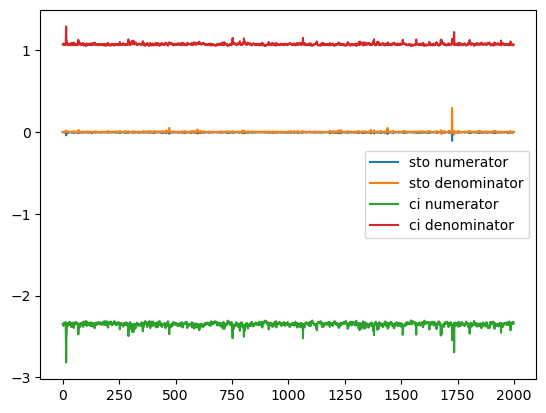

In [14]:
from matplotlib import pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns
plt.plot(numcr_sp.real,label='sto numerator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.plot(numci_sp.real,label='ci numerator')
plt.plot(denci_sp.real,label='ci denominator')
plt.legend()
plt.show()

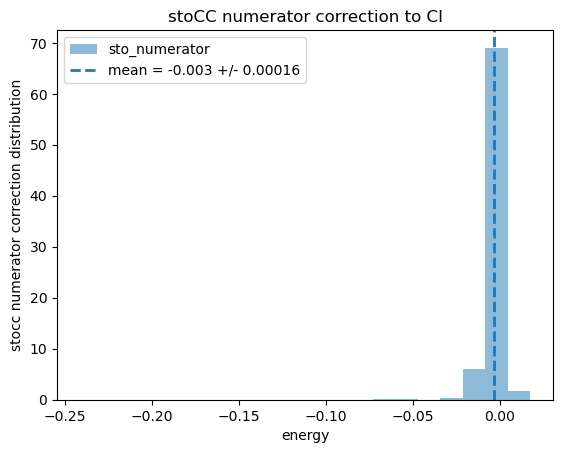

In [74]:
from matplotlib import pyplot as plt
plt.figure()
plt.hist(numcr_sp.real, bins=20, alpha=0.5, density=True, color='C0', label='sto_numerator')
mean = np.mean(numcr_sp.real)
sigma = np.std(numcr_sp.real)/np.sqrt(len(numcr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution")
plt.title("stoCC numerator correction to CI")
plt.legend()
plt.show()

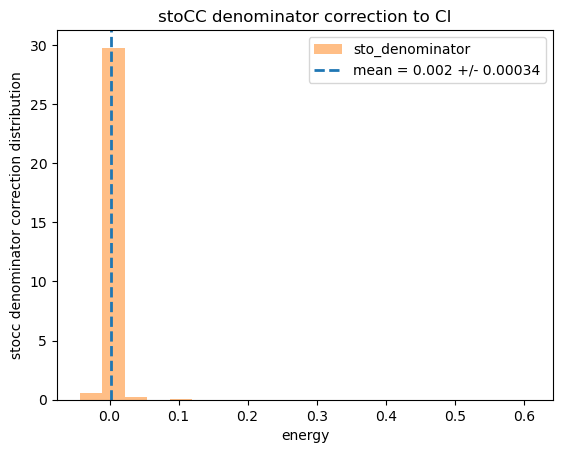

In [75]:
plt.figure()
plt.hist(dencr_sp.real, bins=20, alpha=0.5, density=True, color='C1', label='sto_denominator')
mean = np.mean(dencr_sp.real)
sigma = np.std(dencr_sp.real)/np.sqrt(len(dencr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc denominator correction distribution")
plt.title("stoCC denominator correction to CI")
plt.legend()
plt.show()

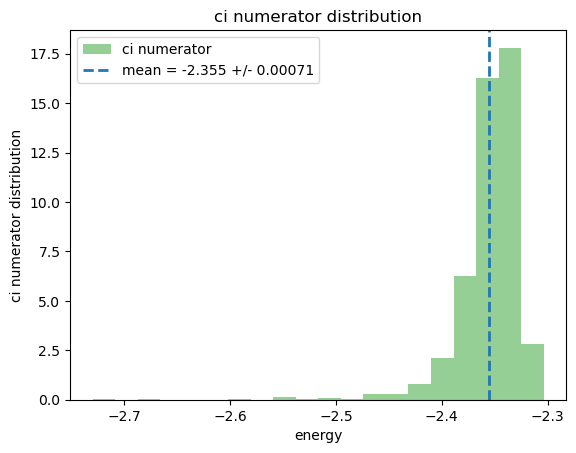

In [76]:
plt.figure()
plt.hist(numci_sp.real, bins=20, alpha=0.5, density=True, color='C2', label='ci numerator')
mean = np.mean((numci_sp).real)
sigma = np.std((numci_sp).real)/np.sqrt(len((numci_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("ci numerator distribution")
plt.title("ci numerator distribution")
plt.legend()
plt.show()

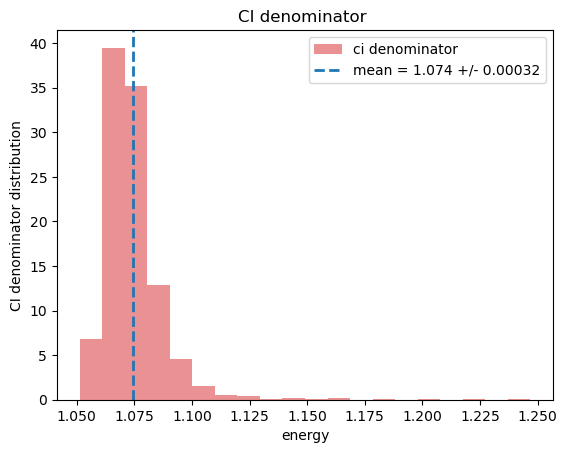

In [77]:
plt.figure()
plt.hist((denci_sp).real, bins=20, alpha=0.5, density=True, color='C3', label='ci denominator')
mean = np.mean((denci_sp).real)
sigma = np.std((denci_sp).real)/np.sqrt(len((denci_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("CI denominator distribution")
plt.title("CI denominator ")
plt.legend()
plt.show()

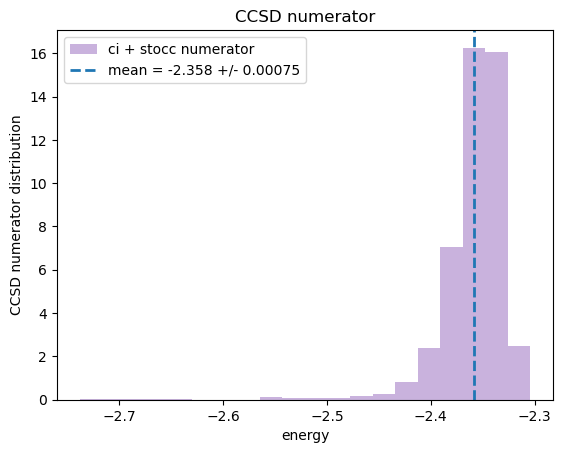

In [78]:
plt.figure()
plt.hist((numci_sp+numcr_sp).real, bins=20, alpha=0.5, density=True, color='C4', label='ci + stocc numerator')
mean = np.mean((numci_sp+numcr_sp).real)
sigma = np.std((numci_sp+numcr_sp).real)/np.sqrt(len((numci_sp+numcr_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("CCSD numerator distribution")
plt.title("CCSD numerator")
plt.legend()
plt.show()

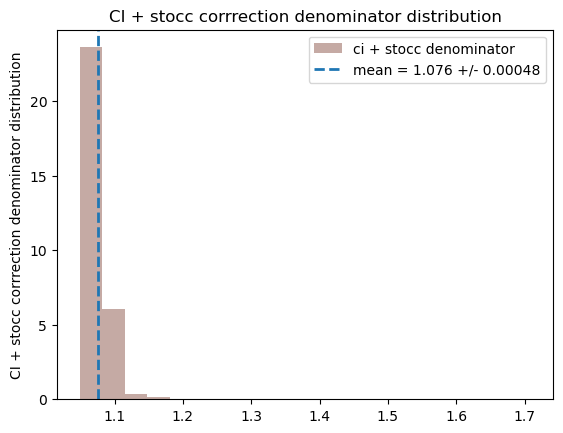

In [79]:
plt.figure()
plt.hist((denci_sp + dencr_sp).real, bins=20, alpha=0.5, density=True, color='C5', label='ci + stocc denominator')
mean = np.mean((denci_sp +dencr_sp).real)
sigma = np.std((denci_sp +dencr_sp).real)/np.sqrt(len((denci_sp +dencr_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
# plt.xlabel("energy")
plt.ylabel("CI + stocc corrrection denominator distribution")
plt.title("CI + stocc corrrection denominator distribution")
plt.legend()
plt.show()

In [80]:
covci

array([[ 0.00104068+0.000000e+00j, -0.00046262+5.174618e-07j],
       [-0.00046262-5.174618e-07j,  0.00020675+0.000000e+00j]])

In [81]:
print(covcc.real)

[[ 1.04067897e-03  3.02053138e-05 -4.62615267e-04 -4.01358507e-05]
 [ 3.02053138e-05  5.34789698e-05 -1.14602821e-05 -1.05838170e-04]
 [-4.62615267e-04 -1.14602821e-05  2.06749909e-04  1.17539480e-05]
 [-4.01358507e-05 -1.05838170e-04  1.17539480e-05  2.46803233e-04]]


In [15]:
decc = [1/(denci+dencr), 
        -(numci+numcr)/(denci+dencr)**2,
        1/(denci+dencr),  
        -(numci+numcr)/(denci+dencr)**2,
        ]
covcc = np.cov([numci_sp[:n+1], denci_sp[:n+1], numcr_sp[:n+1], dencr_sp[:n+1]])
ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))
print(ecc_err)

(0.00025515589738339407+3.74137415877119e-08j)


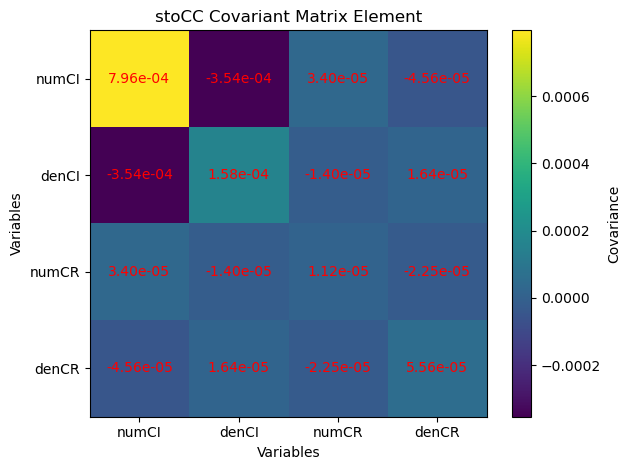

In [ ]:
# 5 slater

var_names = ['numCI', 'denCI',
             'numCR', 'denCR']

plt.figure()
im = plt.imshow(covcc.real, origin='upper', aspect='auto')

plt.colorbar(im, label='Covariance')

# Set tick positions
plt.xticks(np.arange(len(var_names)), var_names) #, rotation=45)
plt.yticks(np.arange(len(var_names)), var_names)

plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('stoCC Covariant Matrix Element')

plt.tight_layout()
# plt.show()

for i in range(covcc.shape[0]):
    for j in range(covcc.shape[1]):
        value = covcc.real[i, j]
        plt.text(j, i, f"{value:.2e}",
                 ha='center', va='center',
                 color='red')
plt.show()

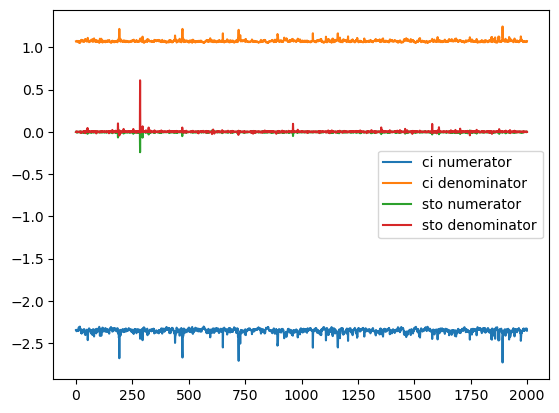

In [88]:
plt.plot(numci_sp.real,label='ci numerator')
plt.plot(denci_sp.real,label='ci denominator')
plt.plot(numcr_sp.real,label='sto numerator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.legend()
plt.show()

In [92]:
deci2 = [1/(denhf+densd),
         -(numhf+numsd)/(denhf+densd)**2,
         1/(denhf+densd),
        -(numhf+numsd)/(denhf+densd)**2,]
covci2 = np.cov([ehf_sp[:n+1],
                 ohf_sp[:n+1],
                 esd_sp[:n+1], 
                 osd_sp[:n+1]
                 ])
eci2_err = np.sqrt(deci2 @ covci2 @ deci2) / np.sqrt((n))
print(eci2_err)

(5.089827653119079e-05+1.966364554782238e-09j)


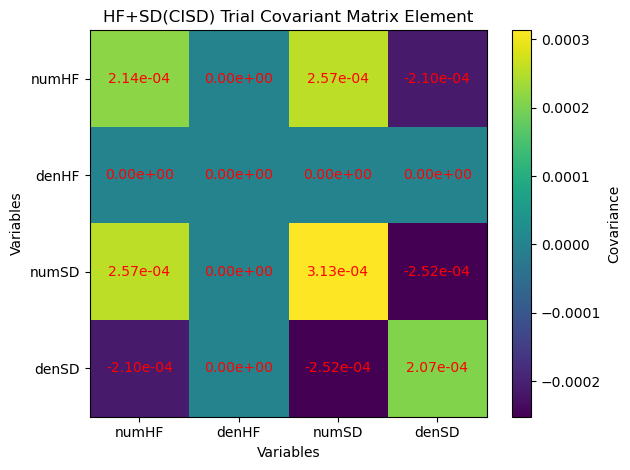

In [93]:
var_names = ['numHF', 'denHF',
             'numSD', 'denSD']

plt.figure()
im = plt.imshow(covci2.real, origin='upper', aspect='auto')

plt.colorbar(im, label='Covariance')

# Set tick positions
plt.xticks(np.arange(len(var_names)), var_names) #, rotation=45)
plt.yticks(np.arange(len(var_names)), var_names)

plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('HF+SD(CISD) Trial Covariant Matrix Element')

plt.tight_layout()
# plt.show()

for i in range(covci2.shape[0]):
    for j in range(covci2.shape[1]):
        value = covci2.real[i, j]
        plt.text(j, i, f"{value:.2e}",
                 ha='center', va='center',
                 color='red')
plt.show()

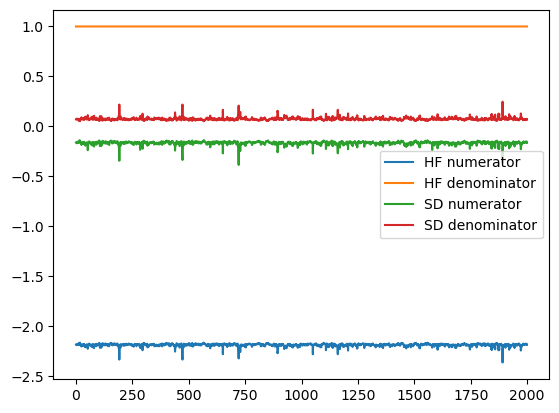

In [86]:
plt.plot(ehf_sp.real,label='HF numerator')
plt.plot(ohf_sp.real,label='HF denominator')
plt.plot(esd_sp.real,label='SD numerator')
plt.plot(osd_sp.real,label='SD denominator')
plt.legend()
plt.show()

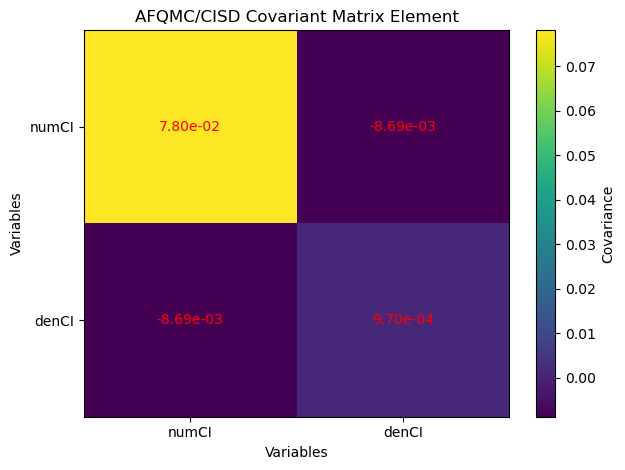

In [24]:
var_names = ['numCI', 'denCI']

plt.figure()
im = plt.imshow(covci.real, origin='upper', aspect='auto')

plt.colorbar(im, label='Covariance')

# Set tick positions
plt.xticks(np.arange(len(var_names)), var_names) #, rotation=45)
plt.yticks(np.arange(len(var_names)), var_names)

plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('AFQMC/CISD Covariant Matrix Element')

plt.tight_layout()
# plt.show()

for i in range(covci.shape[0]):
    for j in range(covci.shape[1]):
        value = covci.real[i, j]
        plt.text(j, i, f"{value:.2e}",
                 ha='center', va='center',
                 color='red')
plt.show()

In [13]:
whf_jk = whf - whf_sp[:n+1]
numci_jk = (whf_numci - whf_sp[:n+1] * numci_sp[:n+1]) / whf_jk
denci_jk = (whf_denci - whf_sp[:n+1] * denci_sp[:n+1]) / whf_jk
numcr_jk = (whf_numcr - whf_sp[:n+1] * numcr_sp[:n+1]) / whf_jk
dencr_jk = (whf_dencr - whf_sp[:n+1] * dencr_sp[:n+1]) / whf_jk


eci_jk = (numci_jk) / (denci_jk)
eci_jk_mean = np.mean(eci_jk)
eci_jk_err = np.std(eci_jk) * np.sqrt(len(eci_jk))
print(f'Jackknife CISD Energy: {eci_jk_mean.real:.6f} +/- {eci_jk_err.real:.6f}')


ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
# for i in range(len(whf_jk)):
#     print(f'  {i+1}  {ecc_jk.real[i]:.6f}')
ecc_jk_mean = np.sum(ecc_jk) / (n+1)
ecc_jk_err = np.sqrt(np.sum((ecc_jk-ecc_jk_mean)**2) * n/(n+1))
print(f'Jackknife CCSD Energy: {ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

Jackknife CISD Energy: -8.751858 +/- 0.000122
Jackknife CCSD Energy: -8.768056 +/- 0.001168


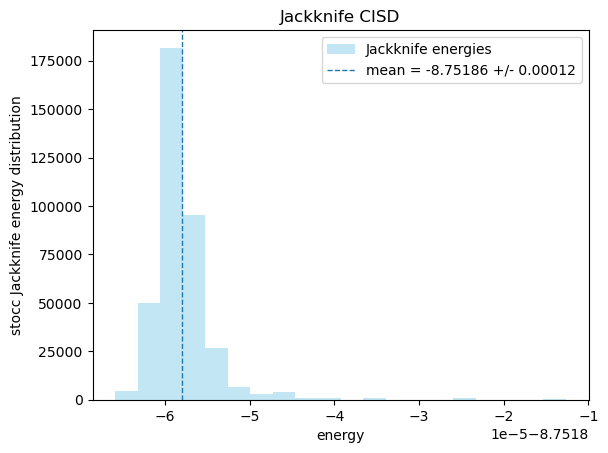

In [12]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(eci_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(eci_jk.real)
sigma = np.std(eci_jk.real) * np.sqrt(len(eci_jk))
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife CISD")
plt.legend()
plt.show()

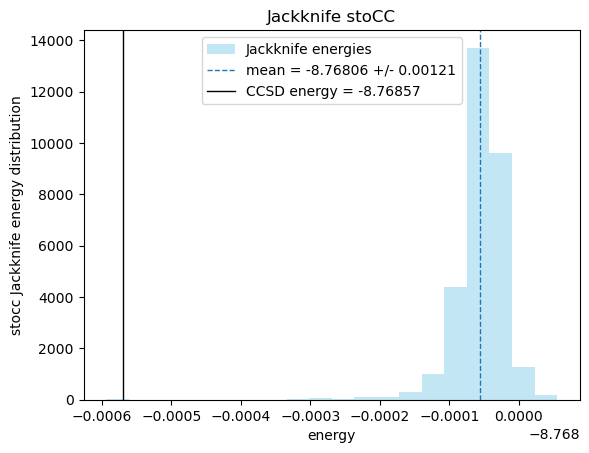

In [11]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(ecc_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(ecc_jk.real)
sigma = np.std(ecc_jk.real) * np.sqrt(len(ecc_jk))
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife stoCC")
plt.legend()
plt.show()

In [69]:
dev = np.abs(ecc_jk.real - ecc_jk.real.mean())

In [ ]:
std = np.std(ecc_jk.real)
z = dev / std
outlier_idx = np.where(z > 10)[0]

In [79]:
outlier_idx

array([673, 852])

In [83]:
median = np.median(ecc_jk.real)
print(median)
mad = np.median(np.abs(ecc_jk.real - median))
print(mad)
z = 0.6745 * (ecc_jk.real - median) / mad
outlier_idx = np.where(np.abs(z) > 20)[0]
print(outlier_idx)

-8.76783682725865
2.3838814004584208e-05
[673 852]


In [87]:
def find_outliers_mad(x, threshold=20.0):
    x = np.asarray(x)

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    # Avoid division-by-zero if all values identical
    if mad == 0:
        return x, np.array([], dtype=int)

    modified_z = 0.6745 * (x - median) / mad
    mask_clean = np.abs(modified_z) <= threshold

    # cleaned = x[mask]
    removed_idx = np.where(~mask_clean)[0]

    return mask_clean, removed_idx

def reomve_outliers(data, mask_clean):
    return [x[mask_clean] for x in data]

In [88]:
mask_clean, outlier_idx = find_outliers_mad(ecc_jk.real, threshold=20.0)
print(outlier_idx)
print(mask_clean.sum())

[673 852]
998


In [90]:
data = [whf_sp, numci_sp, denci_sp, numcr_sp, dencr_sp]
[whf_clean, numci_clean, denci_clean, numcr_clean, dencr_clean] = reomve_outliers(data, mask_clean)

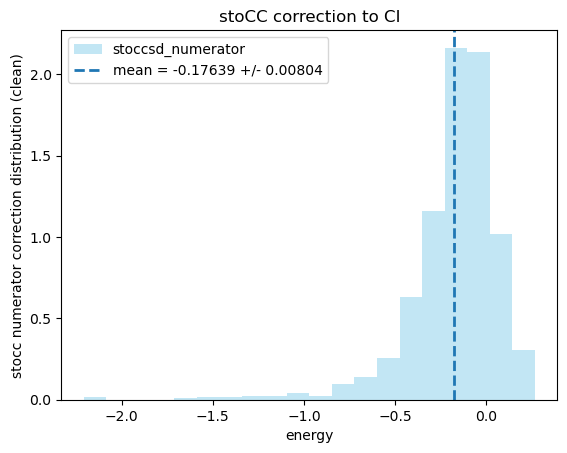

In [95]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(numcr_clean.real, bins=20, alpha=0.5, density=True, color='skyblue', label='stoccsd_numerator')
mean = np.mean(numcr_clean.real)
sigma = np.std(numcr_clean.real)/np.sqrt(len(numcr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

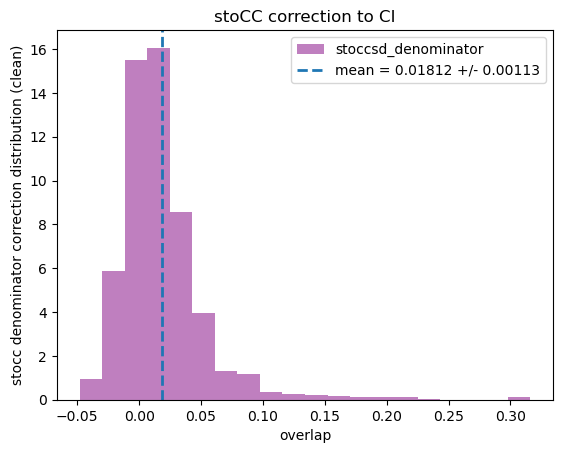

In [94]:
plt.figure()
plt.hist(dencr_clean.real, bins=20, alpha=0.5, density=True, color='purple', label='stoccsd_denominator')
mean = np.mean(dencr_clean.real)
sigma = np.std(dencr_clean.real)/np.sqrt(len(dencr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.xlabel("overlap")
plt.ylabel("stocc denominator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

In [96]:
whf = np.sum(whf_clean)
whf_numci = np.sum(whf_clean * numci_clean)
whf_denci = np.sum(whf_clean * denci_clean)
whf_numcr = np.sum(whf_clean * numcr_clean)
whf_dencr = np.sum(whf_clean * dencr_clean)

In [99]:
(whf_numci + whf_numcr) / (whf_denci + whf_dencr)

np.complex128(-8.76952657069782+0.00014324040333053414j)

In [100]:
whf_jk = whf - whf_clean
numci_jk = (whf_numci - whf_clean * numci_clean) / whf_jk
denci_jk = (whf_denci - whf_clean * denci_clean) / whf_jk
numcr_jk = (whf_numcr - whf_clean * numcr_clean) / whf_jk
dencr_jk = (whf_dencr - whf_clean * dencr_clean) / whf_jk

#CCSD
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
# for i in range(len(whf_jk)):
#     print(f'  {i+1}  {ecc_jk.real[i]:.6f}')
ecc_jk_mean = ecc_jk.mean()
ecc_jk_err = np.std(ecc_jk) * np.sqrt(len(ecc_jk))
print(f'{ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

-8.769527 +/- 0.001809


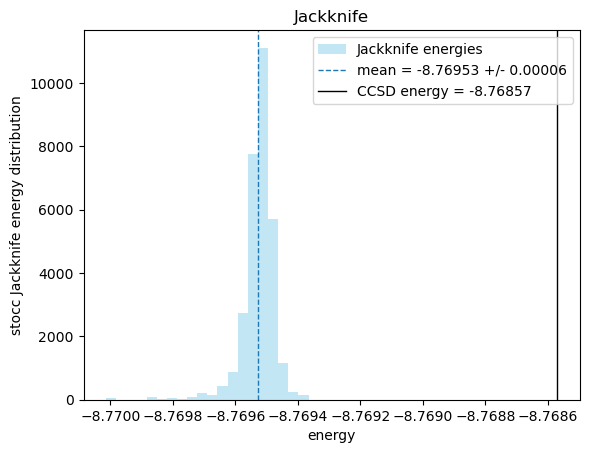

In [101]:
plt.figure()
plt.hist(ecc_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(ecc_jk.real)
sigma = np.std(ecc_jk.real)
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife")
plt.legend()
plt.show()